# 01 - Data Exploration & Sanity Check

**Goal:** Load a single 3D CT scan and its corresponding segmentation mask using MONAI.
 
We will inspect:
1.  **Metadata:** Voxel spacing, orientation, and dimensions.
2.  **Intensity:** The distribution of Hounsfield Units (HU) in the CT scan.
3.  **Labels:** The unique values in the segmentation mask.
4.  **Visualization:** A sanity check to ensure the image and label are aligned.

In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import (
    LoadImaged,
    EnsureChannelFirstd,
    Compose
)
from monai.config import print_config

# Print MONAI config for debugging
print_config()

MONAI version: 1.5.1
Numpy version: 2.2.6
Pytorch version: 2.9.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: /home/<username>/GitHub/mip/mip_env/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: 5.2.0
TorchVision version: 0.24.0+cu128
tqdm version: 4.67.1
lmdb version: 1.7.5
psutil version: 7.1.3
pandas version: 2.3.3
einops version: 0.8.1
transformers version: 4.40.2
mlflow version: 3.6.0
pynrrd version: 1.1.3
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [27]:
# Define the path to the raw data directory. We'll select one patient scan to inspect.
#
# The file structure is assumed to be:
# - `../data/raw/<patient_id>.img.nii/diao_0.nii` for images
# - `../data/raw/<patient_id>.label.nii/label.nii` for labels

# Define the root data directory
DATA_DIR = "../data/raw/"

# --- SELECT PATIENT ---
patient_id = "1" # Select a patient ID
# ----------------------

# Construct the full paths for the image and label files
IMAGE_FILE = os.path.join(DATA_DIR, f"{patient_id}.img.nii", "diao_0.nii")
LABEL_FILE = os.path.join(DATA_DIR, f"{patient_id}.label.nii", "label.nii")

# Create a data dictionary, which is the standard input format for MONAI transforms
data_dict = {"image": IMAGE_FILE, "label": LABEL_FILE}

# Check that the files exist before proceeding
if not (os.path.exists(IMAGE_FILE) and os.path.exists(LABEL_FILE)):
    print(f"Error: Could not find files.")
    print(f"Checked for image: {IMAGE_FILE}")
    print(f"Checked for label: {LABEL_FILE}")
    print("Please update the DATA_DIR, patient_id, IMAGE_FILE, and LABEL_FILE variables.")
else:
    print("Successfully found data files:")
    print(f"Image: {data_dict['image']}")
    print(f"Label: {data_dict['label']}")

Successfully found data files:
Image: ../data/raw/1.img.nii/diao_0.nii
Label: ../data/raw/1.label.nii/label.nii


In [29]:
## Load Data with MONAI
# 
# We use a simple Compose pipeline:
# - LoadImaged: Loads the NIfTI files. We set image_only=False to load the metadata (affine, header) as well.
# - EnsureChannelFirstd: Adds a channel dimension (C) to the beginning, converting the shape from (H, W, D) to (C, H, W, D).

# Define a minimal transform pipeline for loading
load_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=False),
    EnsureChannelFirstd(keys=["image", "label"])
])

# Apply the transforms to our data dictionary
loaded_data = load_transforms(data_dict)

# The output is a MONAI MetaTensor, which is a tensor + metadata
img_metatensor = loaded_data["image"]
lbl_metatensor = loaded_data["label"]

print(f"Image shape (C, H, W, D): {img_metatensor.shape}")
print(f"Label shape (C, H, W, D): {lbl_metatensor.shape}")
print(f"Image data type: {img_metatensor.dtype}")
print(f"Label data type: {lbl_metatensor.dtype}")

Image shape (C, H, W, D): torch.Size([1, 512, 512, 275])
Label shape (C, H, W, D): torch.Size([1, 512, 512, 275])
Image data type: torch.float32
Label data type: torch.float32


In [30]:
## Inspect Metadata (Spacing & Orientation)
# 
# The .meta attribute of the MetaTensor holds all the header information.
#
# - Spacing (pixdim): The physical size of one voxel in millimeters (e.g., `[0.7, 0.7, 1.0]`).
# - Orientation (axcodes): The direction of the axes (e.g., "RAS", "LPI").

# Extract the metadata
img_meta = img_metatensor.meta
lbl_meta = lbl_metatensor.meta

# --- Check Spacing ---
# pixdim is in the metadata. [0] is for batch, [1:4] are the x, y, z dimensions.
spacing = img_meta['pixdim'][1:4]
print(f"\n--- Voxel Spacing (mm) ---")
print(f"Image spacing: {spacing}")
print(f"Label spacing: {lbl_meta['pixdim'][1:4]}")
print(f"Target for preprocessing: [1.0, 1.0, 1.0]")

# --- Check Orientation ---
# We can use nibabel to convert the affine matrix to axis codes
affine = img_meta['original_affine']
orientation = nib.aff2axcodes(affine)
print(f"\n--- Data Orientation ---")
print(f"Image orientation: {orientation}")
print(f"Label orientation: {nib.aff2axcodes(lbl_meta['original_affine'])}")
print(f"Target for preprocessing: ('R', 'A', 'S')")

# --- Check Dimensions ---
print(f"\n--- Data Dimensions (voxels) ---")
print(f"Image dimensions (H, W, D): {img_metatensor.shape[1:]}")


--- Voxel Spacing (mm) ---
Image spacing: [0.37695312 0.37695312 0.5       ]
Label spacing: [0.37695312 0.37695312 0.5       ]
Target for preprocessing: [1.0, 1.0, 1.0]

--- Data Orientation ---
Image orientation: ('L', 'A', 'S')
Label orientation: ('L', 'A', 'S')
Target for preprocessing: ('R', 'A', 'S')

--- Data Dimensions (voxels) ---
Image dimensions (H, W, D): torch.Size([512, 512, 275])


--- Label Stats ---
Unique label values: [0. 1.]
Labels look good (binary 0 and 1).

--- Image Intensity Stats ---
Min: -1024.00
Max: 3071.00
Mean: -212.81
Std Dev: 427.80


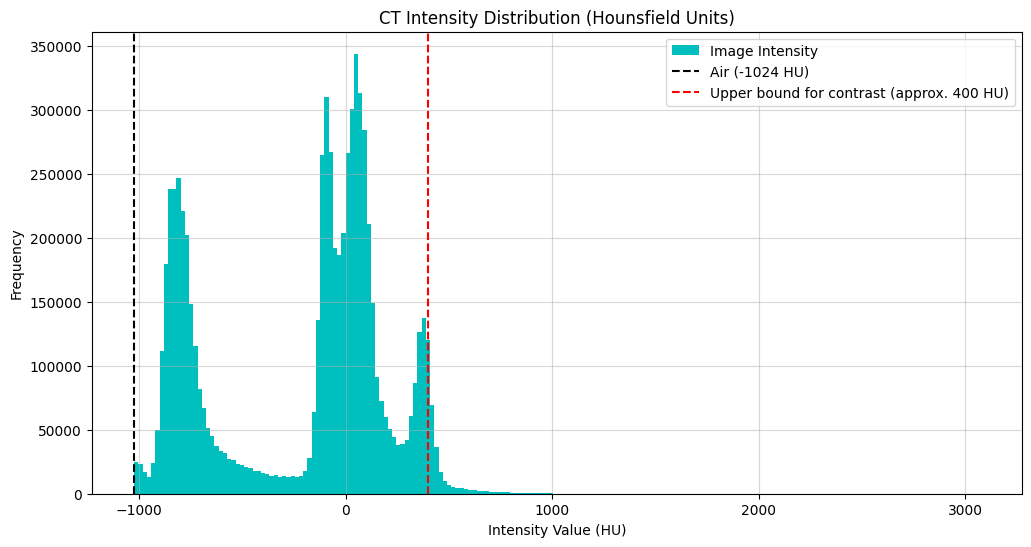

In [35]:
## Inspect Intensity & Label Distributions
#
# - Label: We'll check the unique values. We expect `[0, 1]` for a binary segmentation (0=background, 1=artery).
# - Image: We'll plot a histogram of the CT Hounsfield Units (HU).

# Convert to NumPy arrays for analysis
img_np = img_metatensor.cpu().numpy()
lbl_np = lbl_metatensor.cpu().numpy()

# --- Label Stats ---
print("--- Label Stats ---")
label_values = np.unique(lbl_np)
print(f"Unique label values: {label_values}")
if not np.all(np.isin(label_values, [0, 1])):
    print("Warning: Labels are not [0, 1]. Check your label data.")
else:
    print("Labels look good (binary 0 and 1).")

# --- Image Intensity Stats ---
print("\n--- Image Intensity Stats ---")
print(f"Min: {img_np.min():.2f}")
print(f"Max: {img_np.max():.2f}")
print(f"Mean: {img_np.mean():.2f}")
print(f"Std Dev: {img_np.std():.2f}")

# --- Plot Intensity Histogram ---
# We sample 10% of voxels to make the histogram fast
plt.figure(figsize=(12, 6))
plt.hist(img_np.flatten()[::10], bins=200, color='c', label="Image Intensity")
plt.title("CT Intensity Distribution (Hounsfield Units)")
plt.xlabel("Intensity Value (HU)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.5)

# Add lines for a typical coronary artery window
plt.axvline(-1024, color='k', linestyle='--', label='Air (-1024 HU)')
plt.axvline(400, color='r', linestyle='--', label='Upper bound for contrast (approx. 400 HU)')
plt.legend()
plt.show()

Plotting slice index: 137


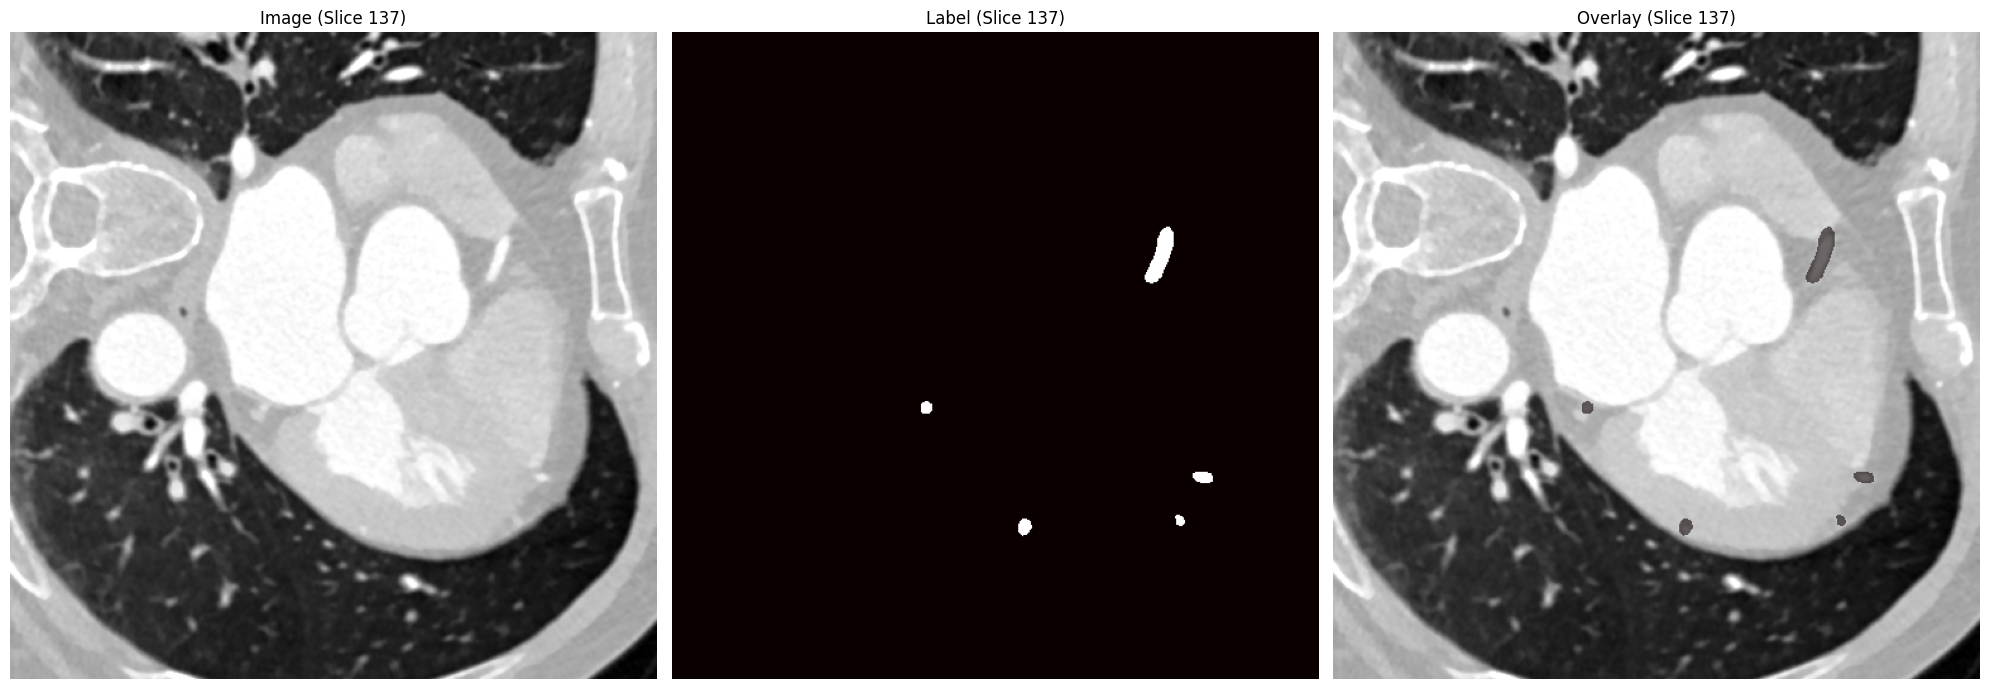

In [36]:
## Visualize an Axial Slice
# 
# Finally, let's plot a slice from the middle of the 3D volume to visually confirm that the image and label are aligned.

# Get the middle slice index from the Depth (D) axis
middle_slice_idx = img_np.shape[3] // 2

# Squeeze the channel dimension (C=1) for plotting
# Shape becomes (H, W)
img_slice = img_np[0, :, :, middle_slice_idx]
lbl_slice = lbl_np[0, :, :, middle_slice_idx]

print(f"Plotting slice index: {middle_slice_idx}")

# --- Plotting ---
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

# Plot Image
ax[0].imshow(img_slice, cmap='gray', vmin=-1024, vmax=400) # Apply our window
ax[0].set_title(f"Image (Slice {middle_slice_idx})")
ax[0].axis('off')

# Plot Label
ax[1].imshow(lbl_slice, cmap='hot')
ax[1].set_title(f"Label (Slice {middle_slice_idx})")
ax[1].axis('off')

# Plot Overlay
ax[2].imshow(img_slice, cmap='gray', vmin=-1024, vmax=400)
# Use a masked array to only show the label where it's > 0
masked_label = np.ma.masked_where(lbl_slice == 0, lbl_slice)
ax[2].imshow(masked_label, cmap='hot', alpha=0.6)
ax[2].set_title(f"Overlay (Slice {middle_slice_idx})")
ax[2].axis('off')

plt.tight_layout()
plt.show()